#question_a
Plot the observations.

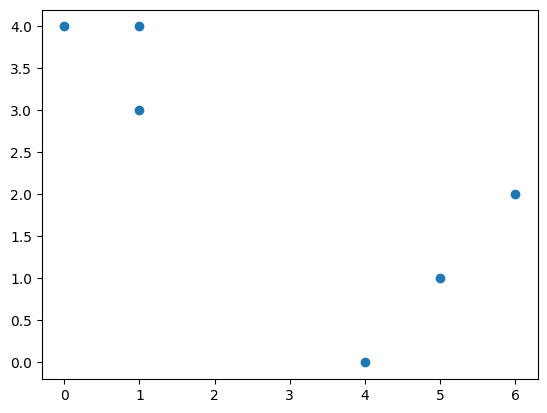

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x1= np.array([1,1,0,5,6,4])
x2= np.array([4,3,4,1,2,0])

plt.scatter(x1, x2)
plt.show()

#question_b
Randomly assign a cluster label to each observation. You can use the np.random.choice() function to do this. Report the cluster labels for each observation.

In [11]:
import numpy as np

x1= np.array([1,1,0,5,6,4])
x2= np.array([4,3,4,1,2,0])

n_observations = len(x1)
k_clusters = 3

np.random.seed(4)
cluster_labels = np.random.choice(range(1, k_clusters+1), size=n_observations)

clusters = {i: [] for i in range(1, k_clusters+1)}

print("ans:")

for i in range(n_observations):
    clusters[cluster_labels[i]].append((float(x1[i]), float(x2[i])))

for cluster_id, points in clusters.items():
    print(f"Cluster {cluster_id}: {points}")


ans:
Cluster 1: [(6.0, 2.0), (4.0, 0.0)]
Cluster 2: [(0.0, 4.0), (5.0, 1.0)]
Cluster 3: [(1.0, 4.0), (1.0, 3.0)]


#question_c
Compute the centroid for each cluster.

In [15]:
centroids = {}
for cluster_id, points in clusters.items():
    points_array = np.array(points)
    centroid = (float(points_array[:,0].mean()), float(points_array[:,1].mean()))
    centroids[cluster_id] = centroid

print('ans:')
for cluster_id, centroid in centroids.items():
    print(f"Centroid of Cluster {cluster_id}: {centroid}")

ans:
Centroid of Cluster 1: (5.0, 1.0)
Centroid of Cluster 2: (2.5, 2.5)
Centroid of Cluster 3: (1.0, 3.5)


#question_d
Assign each observation to the centroid to which it is closest, in terms of Euclidean distance. Report the cluster labels for each observation.

In [32]:
import numpy as np

x1 = np.array([1, 1, 0, 5, 6, 4])
x2 = np.array([4, 3, 4, 1, 2, 0])
observations = np.column_stack((x1, x2))

centroids = {
    1: (5.0, 1.0),
    2: (2.5, 2.5),
    3: (1.0, 3.5)
}

new_clusters = {cid: [] for cid in centroids.keys()}

for obs in observations:
    distances = [np.linalg.norm(obs - np.array(centroids[cid])) for cid in centroids]
    closest_cluster = list(centroids.keys())[np.argmin(distances)]
    new_clusters[closest_cluster].append((int(obs[0]), int(obs[1])))

non_empty_clusters = [points for points in new_clusters.values() if points]

for i, points in enumerate(non_empty_clusters, start=1):
    print(f"Cluster {i}: {points}")


Cluster 1: [(5, 1), (6, 2), (4, 0)]
Cluster 2: [(1, 4), (1, 3), (0, 4)]


#question_e
Repeat (c) and (d) until the answers obtained stop changing.

In [38]:
import numpy as np

x1 = np.array([1, 1, 0, 5, 6, 4])
x2 = np.array([4, 3, 4, 1, 2, 0])
observations = np.column_stack((x1, x2))

centroids = {
    1: (5.0, 1.0),
    2: (2.5, 2.5),
    3: (1.0, 3.5)
}

cluster_labels = list(centroids.keys())
assigned_clusters = np.zeros(len(observations), dtype=int)
new_assigned_clusters = np.zeros(len(observations), dtype=int)

count = 1
converged = False

while not converged:
    new_clusters = {cid: [] for cid in centroids.keys()}
    for i, obs in enumerate(observations):
        distances = [np.linalg.norm(obs - np.array(centroids[cid])) for cid in cluster_labels]
        closest_cluster = cluster_labels[np.argmin(distances)]
        new_assigned_clusters[i] = closest_cluster
        new_clusters[closest_cluster].append((float(obs[0]), float(obs[1])))

    for cid in cluster_labels:
        cluster_points = observations[new_assigned_clusters == cid]
        if len(cluster_points) > 0:
            centroids[cid] = (float(cluster_points[:,0].mean()), float(cluster_points[:,1].mean()))

    print(f"\n--- Iteration {count} ---")
    non_empty_clusters = [pts for pts in new_clusters.values() if pts]
    for i, pts in enumerate(non_empty_clusters, start=1):
        print(f"Cluster {i}: {pts}")

    if np.array_equal(assigned_clusters, new_assigned_clusters):
        converged = True
    else:
        assigned_clusters = new_assigned_clusters.copy()
        count += 1

print(f"\nAfter {count} iterations, clustering has converged.")

non_empty_clusters = [pts for pts in new_clusters.values() if pts]
for i, pts in enumerate(non_empty_clusters, start=1):
    print(f"Cluster {i}: {pts}")



--- Iteration 1 ---
Cluster 1: [(5.0, 1.0), (6.0, 2.0), (4.0, 0.0)]
Cluster 2: [(1.0, 4.0), (1.0, 3.0), (0.0, 4.0)]

--- Iteration 2 ---
Cluster 1: [(5.0, 1.0), (6.0, 2.0), (4.0, 0.0)]
Cluster 2: [(1.0, 4.0), (1.0, 3.0), (0.0, 4.0)]

After 2 iterations, clustering has converged.
Cluster 1: [(5.0, 1.0), (6.0, 2.0), (4.0, 0.0)]
Cluster 2: [(1.0, 4.0), (1.0, 3.0), (0.0, 4.0)]


#question_f
In your plot from (a), color the observations according to the cluster labels obtained.

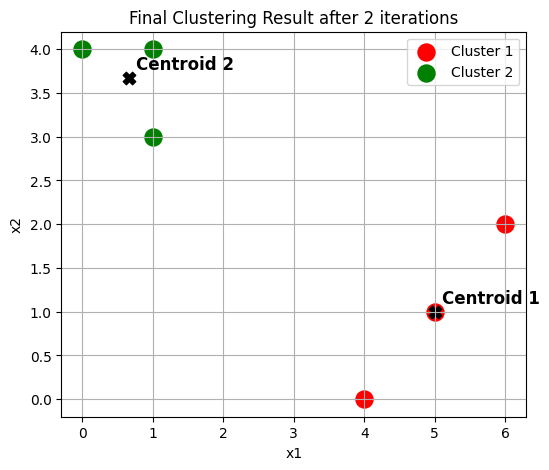

In [43]:
import matplotlib.pyplot as plt
import numpy as np

colors_list = ['red', 'green', 'blue', 'orange', 'purple']
plt.figure(figsize=(6,5))

for i, pts in enumerate(non_empty_clusters, start=1):
    pts_array = np.array(pts)
    plt.scatter(pts_array[:,0], pts_array[:,1], c=colors_list[i-1], label=f'Cluster {i}', s=150)
    centroid_x = pts_array[:,0].mean()
    centroid_y = pts_array[:,1].mean()
    plt.scatter(centroid_x, centroid_y, c='black', marker='X', s=80)
    plt.text(centroid_x+0.1, centroid_y+0.1, f'Centroid {i}', fontsize=12, fontweight='bold')

plt.title(f"Final Clustering Result after {count} iterations")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True)
plt.show()